# 02 · Baselines (from scratch)
Report section: *Baseline methods* + part of *Results*. LDA, QDA, kNN + naive baselines on the leakage-safe split, mean +/- std over 3 symmetrization seeds. Results saved to `report/results_baselines.csv` for the consolidated comparison in `04_results`.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.pipeline import build_dataset
from src.baselines import GaussianClassifier, KNNClassifier, MajorityClassifier
from src.metrics import (accuracy, precision_recall_f1, roc_auc_ovr, log_loss, confusion_matrix,
                         collapse_winner, collapse_method, summarize_over_seeds)
from src.plotting import (plot_confusion_matrix, plot_decision_regions, save_fig,
                          use_report_style, nice_label)
use_report_style()

## 1. Baseline panel, seed-averaged (D1)
Each model trains on the symmetrized train and is scored on the original-corner test (same fights as the always-red / market references). QDA is regularized (reg=1.0) - unregularized it is ill-conditioned in ~114 dims. We collapse the 6-class prediction to winner (Red/Blue) and method (KO/SUB/DEC) for readable, reference-comparable numbers.

In [2]:
SEEDS = [0, 1, 2]
specs = {'LDA': lambda: GaussianClassifier('lda'),
         'QDA': lambda: GaussianClassifier('qda', reg=1.0),
         'kNN (k=15)': lambda: KNNClassifier(k=15),
         'majority': lambda: MajorityClassifier()}
acc6, winacc, metacc, ll, f1m, auc = ({n: [] for n in specs} for _ in range(6))
always_red = []
for s in SEEDS:
    ds = build_dataset(seed=s)
    Xtr, ytr, Xte, yte = ds.X_train.values, ds.y_train.values, ds.X_test.values, ds.y_test.values
    for n, make in specs.items():
        m = make().fit(Xtr, ytr)
        proba = m.predict_proba(Xte)
        pred = m.classes_[proba.argmax(1)]
        acc6[n].append(accuracy(yte, pred))
        winacc[n].append(accuracy(collapse_winner(yte), collapse_winner(pred)))
        metacc[n].append(accuracy(collapse_method(yte), collapse_method(pred)))
        ll[n].append(log_loss(yte, proba, classes=m.classes_))
        f1m[n].append(precision_recall_f1(yte, pred, classes=m.classes_)['macro_f1'])
        auc[n].append(roc_auc_ovr(yte, proba, classes=m.classes_))
    always_red.append((collapse_winner(yte) == 'Red').mean())
rows = []
for n in specs:
    a_m, a_s = summarize_over_seeds(acc6[n]); w_m, w_s = summarize_over_seeds(winacc[n])
    me_m, _ = summarize_over_seeds(metacc[n]); l_m, _ = summarize_over_seeds(ll[n])
    f_m, _ = summarize_over_seeds(f1m[n]); au_m, _ = summarize_over_seeds(auc[n])
    rows.append({'model': n, 'acc6_mean': a_m, 'acc6_std': a_s, 'winner_mean': w_m,
                 'winner_std': w_s, 'method_mean': me_m, 'macro_f1_mean': f_m,
                 'roc_auc_mean': au_m, 'logloss_mean': l_m})
res = pd.DataFrame(rows).set_index('model').round(3)
res.to_csv('../report/results_baselines.csv')
print(f'always-red (winner): {np.mean(always_red):.3f}  | coin-flip: 0.500')
print('macro_f1 / roc_auc are over the full 6-class target (one-vs-rest, macro-averaged).')
res

always-red (winner): 0.562  | coin-flip: 0.500
macro_f1 / roc_auc are over the full 6-class target (one-vs-rest, macro-averaged).


,acc6_mean,acc6_std,winner_mean,winner_std,method_mean,macro_f1_mean,roc_auc_mean,logloss_mean
model,,,,,,,,
LDA,0.343,0.004,0.626,0.004,0.516,0.315,0.685,1.592
QDA,0.230,0.018,0.567,0.029,0.371,0.220,0.624,3.134
kNN (k=15),0.282,0.004,0.550,0.006,0.497,0.221,0.595,3.642
majority,0.266,0.025,0.521,0.059,0.514,0.070,0.500,1.702


**Reading the baseline panel.** LDA is the strongest baseline (winner ~0.63, lowest log-loss) and QDA the weakest, the opposite of what extra flexibility would suggest. The cause is dimensionality: with ~114 features QDA estimates a full covariance *per class*, which is ill-conditioned, so even regularized (reg=1.0) it stays poorly calibrated (its large log-loss). kNN also degrades as distances concentrate in high dimensions. The new macro-F1 and ROC-AUC columns tell the same story from the imbalance and ranking sides: macro-F1 is low (the rare submission classes are seldom recovered) and ROC-AUC sits only modestly above 0.5 (weak separability). Net: the signal is close to linear, so the simplest generative model wins; notebook 04 (E3) checks whether PCA rescues QDA/kNN, and it does not.

## 2. Confusion matrix (best baseline, single seed)

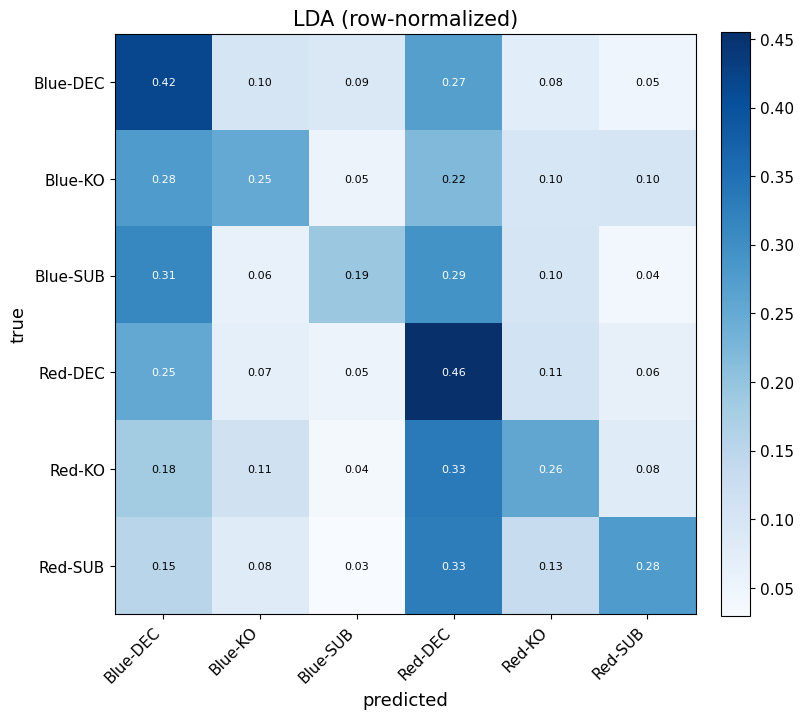

In [3]:
ds = build_dataset(seed=0)
Xtr, ytr, Xte, yte = ds.X_train.values, ds.y_train.values, ds.X_test.values, ds.y_test.values
lda = GaussianClassifier('lda').fit(Xtr, ytr)
M, classes = confusion_matrix(yte, lda.predict(Xte), classes=lda.classes_)
plot_confusion_matrix(M, classes, normalize=True); plt.title('LDA (row-normalized)')
save_fig('confusion_matrix_baseline'); plt.show()

**How to read this 6x6 matrix.** Rows are the true class, columns the predicted class, and each row is normalized, so a cell answers "of all fights that truly ended this way, what fraction did the model predict as that column?" A perfect model would be bright only on the diagonal. Instead the mass piles into the two decision *columns* (Red-DEC, Blue-DEC): the model defaults to "this goes to a decision," because decisions are by far the most common outcome. The KO rows show some diagonal signal, but the submission rows are nearly empty on the diagonal: submissions are both rare and the hardest finish to predict from pre-fight features. SAMME (notebook 03) shows the same pattern.